In [94]:
import numpy as np
from functools import reduce
from scipy.linalg import eigh, norm
import sys
import os


module_dir = os.path.abspath('../src')

# Add the directory to sys.path
sys.path.insert(0, module_dir)

import PySaRLAC as sl


sx = np.array([[0., 1.], [1., 0.]])
sy = np.array([[0., -1j], [1j, 0.]])
sz = np.array([[1., 0.], [0., -1.]])
id2 = np.eye(2)

def kron_n(op_list):
    return reduce(np.kron, op_list)

def pauli_op_on_site(pauli, site, N):
    ops = [id2] * N
    ops[site] = pauli
    return kron_n(ops)

def build_tfim_hamiltonian(N, J, h, periodic=False):
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)
    for i in range(N-1):
        H += -J * ((pauli_op_on_site(sz, i, N) @ pauli_op_on_site(sz, i+1, N)) - np.eye(dim))
    if periodic and N>1:
        H += -J * ((pauli_op_on_site(sz, N-1, N) @ pauli_op_on_site(sz, 0, N))  - np.eye(dim))
    for i in range(N):
        H += -h * (pauli_op_on_site(sx, i, N) - np.eye(dim))
    return H 

def expectation(state, operator):
    return np.vdot(state, operator @ state)

def matrix_element(bra, operator, ket):
    return np.vdot(bra, operator @ ket)

def correlator_matrix_from_eigstates(ops, evals, evecs, t):

    psi0 = evecs[:, 0]
    n_ops = len(ops)
    C = np.zeros((n_ops, n_ops), dtype=complex)
    n_states = evecs.shape[1]
    M = np.zeros((n_states, n_ops), dtype=complex)  # M[k,j] = <k| O_j |0>
    for k in range(n_states):
        psi_k = evecs[:, k]
        for j, Oj in enumerate(ops):
            M[k, j] = matrix_element(psi_k, Oj, psi0)
    
    weights = np.exp(-evals * t)
    for i in range(n_ops):
        for j in range(n_ops):
            C[i, j] = np.sum(weights * np.conjugate(M[:, i]) * M[:, j])
    return C

def build_trial_state_from_vector(v, ops, psi0):

    vec = np.zeros_like(psi0, dtype=complex)
    for i, vi in enumerate(v):
        vec += vi * (ops[i] @ psi0)
    nrm = norm(vec)
    if nrm == 0:
        return vec, 0.0
    return vec / nrm, nrm

#try with 3 sites and get projection ops from gevp, use 0 statiscal error
N = 4        # number of spins
J = .1
h = 0.15   
periodic = False

t0 = 0
Lt  = 32

H = build_tfim_hamiltonian(N, J, h, periodic=periodic)

evals, evecs = eigh(H)

evals = evals 

dim = 2**N

O_g  = sum(pauli_op_on_site(sx, i, N) for i in range(N))
O_e1 = pauli_op_on_site(sz, 0, N)
O_e2 = pauli_op_on_site(sz, 1 % N, N)
ops = [O_g, O_e1, O_e2]
labels = ["O_g = Σ Sx", "O_e1 = Sz(0)", "O_e2 = Sz(1)"]

# Build correlator matrices at t0 and t
Ct0 = correlator_matrix_from_eigstates(ops, evals, evecs, 1)
#Ct  = correlator_matrix_from_eigstates(ops, evals, evecs, t)


def noisy_array(x, N, sigma=1000.0):
    """
    Returns an array of length N where each element is x + Gaussian noise.
    
    x     : base value
    N     : number of samples
    sigma : standard deviation of the noise
    """
    noise = np.random.normal(loc=1, scale=sigma, size=N)
    return x*noise

N = 400
raw = [ [None for j in range(3)] for i in range(3)]
jack = [ [None for j in range(3)] for i in range(3)]
for i in range(3):
    for j in range(3):
        raw[i][j] = sl.CorrelationFunction(Lt)
        
        for t in range(Lt):
            
            
            rdist = sl.RawDataDistribution(400)
            jvals = noisy_array(correlator_matrix_from_eigstates(ops, evals, evecs, t)[i][j],400, sigma=1*np.exp(0.1*t))            
            
            
            for s in range(400):
                rdist[s] = jvals[s]  
            jdist = sl.JackknifeDistribution(rdist)
            
            raw[i][j].setValue(t, jdist)
            
            
            
            raw[i][j].setCoord(t, float(t))

    
#evidence of excited state contamination, mix operators with 4th state
#use gevp to come up with ops
            
        
        #jack[i][j] = raw[i][j].resample(sl.JackknifeDistribution)

#create raw dist.
#make plots of jackknife
#make corr symmetric
# corrs = sl.CorrelationFunction(Lt)

# for t in range(t0, Lt):
#     corrs.setCoord(t, float(t))
    # corrs.append(correlator_matrix_from_eigstates(ops, evals, evecs, t))
print(evecs[0].T @ O_e2 @ evecs[0])

print(evecs[1].T @ O_e2 @ evecs[1])
print(evecs[2].T @ O_e2 @ evecs[2])

(0.3370641230123325+0j)
(-0.10572053729261395+0j)
(0.10572053729262489+0j)


/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/RawDataDistribution.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  self.samples[i] = val


In [85]:
def gevp_output(input_data, E_n, t_max, Dt, rebasing = False, rebased_time_slice = 1, rebased_Dt = 2):
    #time_array = np.arange(0, t_max)
    data = sl.CorrelationFunction(t_max)
    if rebasing == False:
        gevp_obj = sl.GEVP_OG(input_data)
        for i in range(0,t_max-1):
            for j in range(i+1, t_max):
                if j-i == Dt:
                    data.setValue(j, gevp_obj.run(i,j)[E_n])
                    data.setCoord(j, float(j))
        return  data
    if rebasing == True:
        gevp_obj = sl.GEVP(input_data)
        for i in range(0,t_max-1):
            for j in range(i+1, t_max):
                if j-i == Dt:
                    data.setValue(j, gevp_obj.run(i,j, rebased_time_slice, rebased_time_slice + 
                                                  rebased_Dt)[E_n])
                    data.setCoord(j, float(j))
        return data
    


In [86]:
#compare gevp with system that has # eigenvalues as states in gevp

gevp_0 = gevp_output(raw, 0, 18, 1)
gevp_1 = gevp_output(raw, 1, 18, 1)
gevp_2 = gevp_output(raw, 2, 18, 1)


/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/GEVP.py:273: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[i] = eigvals[idx]
/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/GEVP.py:259: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[i] = eigvals[idx2]


(0.0, 1.0)

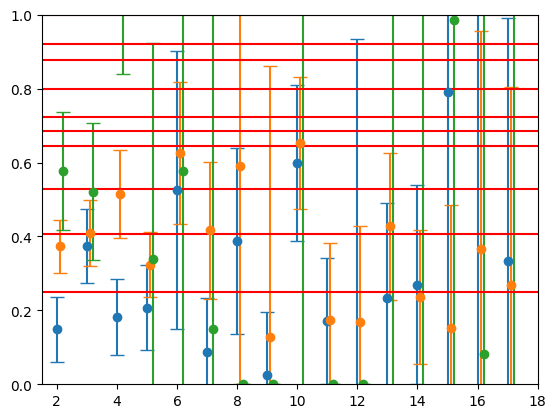

In [88]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots()

ax.errorbar(*gevp_0.plotInputs(), label = r"Removed $\sigma$ op", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_1.plotInputs(x_offset=0.1), label = r"Removed $\sigma$ op", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_2.plotInputs(x_offset=0.2), label = r"Removed $\sigma$ op", marker="o", capsize=5, linestyle='')
ax.hlines(evals, 1.5, 18, color = "red")
ax.set_xlim(1.5, 18)
ax.set_ylim(0, 1)

#look into the errors more closely, look into misordering of the eigenvalues, histogramg of jackknife

In [ ]:
for i in range(3):
    print()

(0.26905954138075355+0j)

In [53]:
gevp_0_r = gevp_output(raw, 0, 18, 1, rebasing=True)
gevp_1_r = gevp_output(raw, 1, 18, 1, rebasing=True)

/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/GEVP.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[i] = eigvals[idx]
/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/GEVP.py:99: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[i] = eigvals[idx2]


(0.0, 7.0)

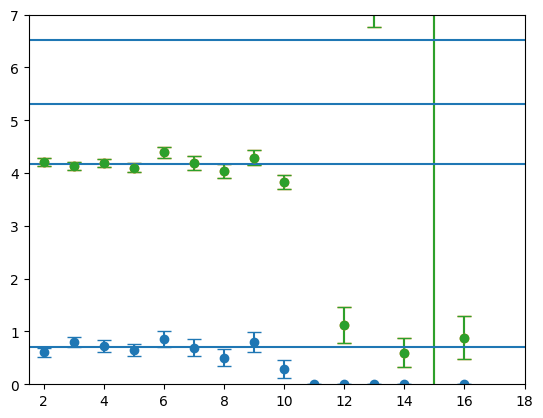

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots()

ax.errorbar(*gevp_0_r.plotInputs(), label = r"Removed $\sigma$ op", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_1_r.plotInputs(), label = r"Removed $\sigma$ op", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_1_r.plotInputs(), label = r"Removed $\sigma$ op", marker="o", capsize=5, linestyle='')

ax.hlines(evals, 1.5, 18)
ax.set_xlim(1.5, 18)
ax.set_ylim(0, 7)

#Throw away entire dist. if gevps fails

In [ ]:
0.5 * (A/2 + A.T/2)

1.0000000000000001e+65

In [121]:
np.log(-1)

/tmp/ipykernel_99759/153577755.py:1: RuntimeWarning: invalid value encountered in log
  np.log(-1)


np.float64(nan)